=== グラフ生成条件 ===
N = 100
M = 2
seed = 42
ER の接続確率 p = 0.040404

=== BA ===
ノード数                 : 100
エッジ数                 : 196
平均次数                 : 3.9200
密度                     : 0.039596
平均クラスタ係数         : 0.163388
平均最短距離(最大連結成分): 2.852727
最大連結成分比率         : 1.000000

次数エントロピー         : 2.290220 bits
正規化 次数エントロピー  : 0.638841
構造エントロピー         : 6.138589 bits
正規化 構造エントロピー  : 0.923950
von Neumann entropy      : 5.982654 bits
正規化 von Neumann entr. : 0.900479

=== ER ===
ノード数                 : 100
エッジ数                 : 177
平均次数                 : 3.5400
密度                     : 0.035758
平均クラスタ係数         : 0.018500
平均最短距離(最大連結成分): 3.550687
最大連結成分比率         : 0.970000

次数エントロピー         : 2.921961 bits
正規化 次数エントロピー  : 0.879598
構造エントロピー         : 6.414887 bits
正規化 構造エントロピー  : 0.965537
von Neumann entropy      : 6.213814 bits
正規化 von Neumann entr. : 0.935272

=== 比較表 ===
graph_name  nodes  edges  avg_degree  density  average_clustering  average_shortest_path_lcc  largest_component_ratio  de

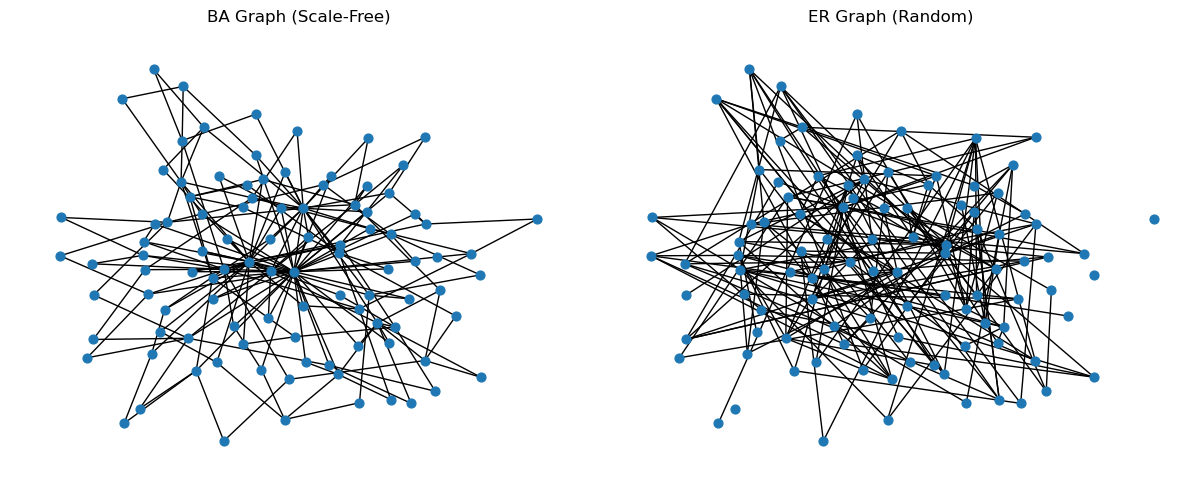

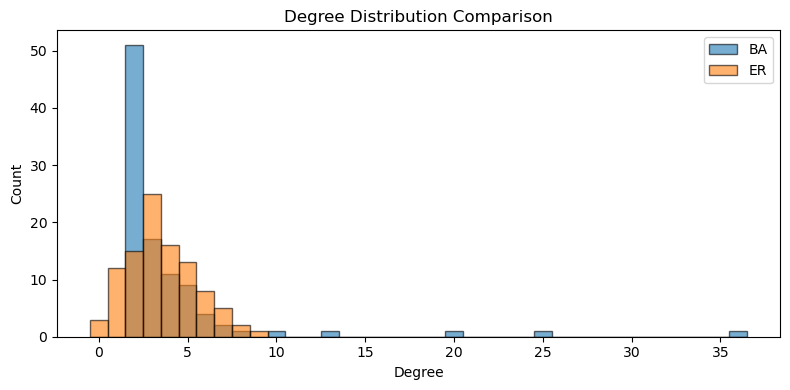

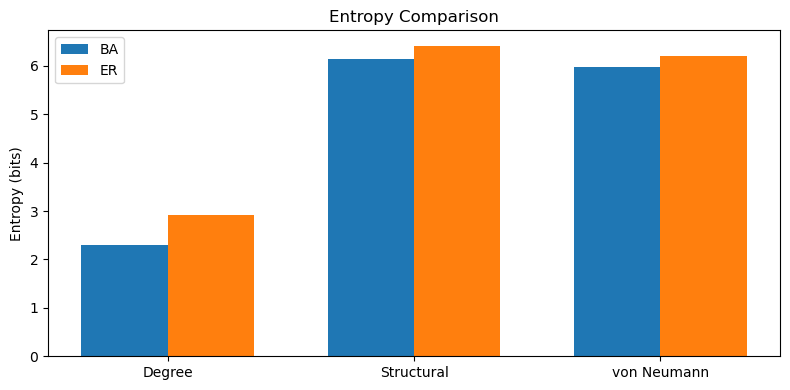

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter


# =========================================
# 0. 設定
# =========================================
N = 100
M = 2
SEED = 42


# =========================================
# 1. グラフ生成
# =========================================
def generate_graphs(n=100, m=2, seed=42):
    # BAグラフ
    G_ba = nx.barabasi_albert_graph(n=n, m=m, seed=seed)

    # BAの平均次数 ≈ 2m に合わせた ER グラフ
    p_er = (2 * m) / (n - 1)
    G_er = nx.erdos_renyi_graph(n=n, p=p_er, seed=seed)

    return G_ba, G_er, p_er


# =========================================
# 2. 次数エントロピー
#    H_deg = - sum_k p(k) log2 p(k)
# =========================================
def degree_entropy(G):
    degrees = [d for _, d in G.degree()]
    count = Counter(degrees)
    N_nodes = sum(count.values())

    p = np.array([c / N_nodes for c in count.values()], dtype=float)

    if len(p) == 0:
        return 0.0, 0.0, degrees, count

    H = -np.sum(p * np.log2(p))
    H_norm = H / np.log2(len(p)) if len(p) > 1 else 0.0

    return H, H_norm, degrees, count


# =========================================
# 3. 構造エントロピー
#    p_i = degree(i) / sum_j degree(j)
#    H_struct = - sum_i p_i log2 p_i
# =========================================
def structural_entropy(G):
    degrees = np.array([d for _, d in G.degree()], dtype=float)
    volume = degrees.sum()   # = 2|E|

    if volume <= 0:
        return 0.0, 0.0, np.zeros(len(degrees))

    p = degrees / volume
    p_nonzero = p[p > 0]

    H = -np.sum(p_nonzero * np.log2(p_nonzero))
    H_norm = H / np.log2(len(degrees)) if len(degrees) > 1 else 0.0

    return H, H_norm, p


# =========================================
# 4. von Neumann entropy
#    L = D - A
#    rho = L / Tr(L)
#    H_vN = -Tr(rho log2 rho)
#         = - sum_i lambda_i log2 lambda_i
# =========================================
def von_neumann_entropy(G):
    n = G.number_of_nodes()

    if n == 0:
        return 0.0, 0.0, np.array([])

    A = nx.to_numpy_array(G, dtype=float)
    deg = A.sum(axis=1)
    L = np.diag(deg) - A

    trL = np.trace(L)
    if trL <= 0:
        return 0.0, 0.0, np.array([])

    rho = L / trL

    eigvals = np.linalg.eigvalsh(rho)
    eigvals = np.real(eigvals)
    eigvals = eigvals[eigvals > 1e-12]  # 数値誤差でのゼロ除去

    if len(eigvals) == 0:
        return 0.0, 0.0, eigvals

    H = -np.sum(eigvals * np.log2(eigvals))
    H_norm = H / np.log2(n) if n > 1 else 0.0

    return H, H_norm, eigvals


# =========================================
# 5. その他の基本統計
# =========================================
def graph_basic_stats(G):
    n = G.number_of_nodes()
    e = G.number_of_edges()
    degrees = np.array([d for _, d in G.degree()], dtype=float)

    avg_degree = degrees.mean() if len(degrees) > 0 else 0.0
    density = nx.density(G) if n > 1 else 0.0

    if n > 0:
        clustering = nx.average_clustering(G)
    else:
        clustering = 0.0

    # 連結でない場合は最大連結成分で平均最短距離を計算
    if n > 0 and e > 0:
        if nx.is_connected(G):
            avg_shortest_path = nx.average_shortest_path_length(G)
            giant_ratio = 1.0
        else:
            largest_cc = max(nx.connected_components(G), key=len)
            G_cc = G.subgraph(largest_cc).copy()
            avg_shortest_path = nx.average_shortest_path_length(G_cc)
            giant_ratio = G_cc.number_of_nodes() / n
    else:
        avg_shortest_path = np.nan
        giant_ratio = np.nan

    return {
        "nodes": n,
        "edges": e,
        "avg_degree": avg_degree,
        "density": density,
        "average_clustering": clustering,
        "average_shortest_path_lcc": avg_shortest_path,
        "largest_component_ratio": giant_ratio,
    }


# =========================================
# 6. グラフ解析まとめ
# =========================================
def analyze_graph(G, name="Graph"):
    stats = graph_basic_stats(G)

    H_deg, H_deg_norm, degrees, degree_count = degree_entropy(G)
    H_struct, H_struct_norm, node_prob = structural_entropy(G)
    H_vn, H_vn_norm, eigvals = von_neumann_entropy(G)

    result = {
        "graph_name": name,

        "nodes": stats["nodes"],
        "edges": stats["edges"],
        "avg_degree": stats["avg_degree"],
        "density": stats["density"],
        "average_clustering": stats["average_clustering"],
        "average_shortest_path_lcc": stats["average_shortest_path_lcc"],
        "largest_component_ratio": stats["largest_component_ratio"],

        "degree_entropy_bits": H_deg,
        "degree_entropy_norm": H_deg_norm,

        "structural_entropy_bits": H_struct,
        "structural_entropy_norm": H_struct_norm,

        "von_neumann_entropy_bits": H_vn,
        "von_neumann_entropy_norm": H_vn_norm,

        "degrees": degrees,
        "degree_count": degree_count,
        "node_probability": node_prob,
        "laplacian_density_eigenvalues": eigvals,
    }
    return result


# =========================================
# 7. 表示関数
# =========================================
def print_result(res):
    print(f"=== {res['graph_name']} ===")
    print(f"ノード数                 : {res['nodes']}")
    print(f"エッジ数                 : {res['edges']}")
    print(f"平均次数                 : {res['avg_degree']:.4f}")
    print(f"密度                     : {res['density']:.6f}")
    print(f"平均クラスタ係数         : {res['average_clustering']:.6f}")

    if pd.notna(res["average_shortest_path_lcc"]):
        print(f"平均最短距離(最大連結成分): {res['average_shortest_path_lcc']:.6f}")
    else:
        print("平均最短距離(最大連結成分): nan")

    if pd.notna(res["largest_component_ratio"]):
        print(f"最大連結成分比率         : {res['largest_component_ratio']:.6f}")
    else:
        print("最大連結成分比率         : nan")

    print()
    print(f"次数エントロピー         : {res['degree_entropy_bits']:.6f} bits")
    print(f"正規化 次数エントロピー  : {res['degree_entropy_norm']:.6f}")

    print(f"構造エントロピー         : {res['structural_entropy_bits']:.6f} bits")
    print(f"正規化 構造エントロピー  : {res['structural_entropy_norm']:.6f}")

    print(f"von Neumann entropy      : {res['von_neumann_entropy_bits']:.6f} bits")
    print(f"正規化 von Neumann entr. : {res['von_neumann_entropy_norm']:.6f}")
    print()


def results_to_dataframe(results):
    rows = []
    for res in results:
        rows.append({
            "graph_name": res["graph_name"],
            "nodes": res["nodes"],
            "edges": res["edges"],
            "avg_degree": res["avg_degree"],
            "density": res["density"],
            "average_clustering": res["average_clustering"],
            "average_shortest_path_lcc": res["average_shortest_path_lcc"],
            "largest_component_ratio": res["largest_component_ratio"],
            "degree_entropy_bits": res["degree_entropy_bits"],
            "degree_entropy_norm": res["degree_entropy_norm"],
            "structural_entropy_bits": res["structural_entropy_bits"],
            "structural_entropy_norm": res["structural_entropy_norm"],
            "von_neumann_entropy_bits": res["von_neumann_entropy_bits"],
            "von_neumann_entropy_norm": res["von_neumann_entropy_norm"],
        })
    return pd.DataFrame(rows)


# =========================================
# 8. 可視化
# =========================================
def plot_graphs(G_ba, G_er):
    plt.figure(figsize=(12, 5))

    # 同じレイアウトにして比較しやすくする
    pos = nx.spring_layout(G_ba, seed=SEED)

    plt.subplot(1, 2, 1)
    nx.draw(G_ba, pos, node_size=40, with_labels=False)
    plt.title("BA Graph (Scale-Free)")

    plt.subplot(1, 2, 2)
    nx.draw(G_er, pos, node_size=40, with_labels=False)
    plt.title("ER Graph (Random)")

    plt.tight_layout()
    plt.show()


def plot_degree_histograms(res_ba, res_er):
    deg_ba = res_ba["degrees"]
    deg_er = res_er["degrees"]

    min_bin = min(min(deg_ba), min(deg_er))
    max_bin = max(max(deg_ba), max(deg_er))

    plt.figure(figsize=(8, 4))

    plt.hist(
        deg_ba,
        bins=range(min_bin, max_bin + 2),
        alpha=0.6,
        label="BA",
        edgecolor="black",
        align="left",
    )

    plt.hist(
        deg_er,
        bins=range(min_bin, max_bin + 2),
        alpha=0.6,
        label="ER",
        edgecolor="black",
        align="left",
    )

    plt.xlabel("Degree")
    plt.ylabel("Count")
    plt.title("Degree Distribution Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_entropy_comparison(res_ba, res_er):
    labels = ["Degree", "Structural", "von Neumann"]
    ba_vals = [
        res_ba["degree_entropy_bits"],
        res_ba["structural_entropy_bits"],
        res_ba["von_neumann_entropy_bits"],
    ]
    er_vals = [
        res_er["degree_entropy_bits"],
        res_er["structural_entropy_bits"],
        res_er["von_neumann_entropy_bits"],
    ]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(8, 4))
    plt.bar(x - width / 2, ba_vals, width, label="BA")
    plt.bar(x + width / 2, er_vals, width, label="ER")

    plt.xticks(x, labels)
    plt.ylabel("Entropy (bits)")
    plt.title("Entropy Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================
# 9. 実行
# =========================================
def main():
    G_ba, G_er, p_er = generate_graphs(n=N, m=M, seed=SEED)

    print("=== グラフ生成条件 ===")
    print(f"N = {N}")
    print(f"M = {M}")
    print(f"seed = {SEED}")
    print(f"ER の接続確率 p = {p_er:.6f}")
    print()

    res_ba = analyze_graph(G_ba, "BA")
    res_er = analyze_graph(G_er, "ER")

    print_result(res_ba)
    print_result(res_er)

    df = results_to_dataframe([res_ba, res_er])

    print("=== 比較表 ===")
    print(df.to_string(index=False))
    print()

    plot_graphs(G_ba, G_er)
    plot_degree_histograms(res_ba, res_er)
    plot_entropy_comparison(res_ba, res_er)

    return df, res_ba, res_er


if __name__ == "__main__":
    df_result, result_ba, result_er = main()